# Suburb Ranking

This notebook builds transparent suburb-level decision scores from the cleaned rental listings and external features.

The results are relative rankings within the eligible Domain listing sample, not claims about every Victorian suburb. Four outputs are reported:

1. **Affordability proxy** - property-mix-adjusted asking rent relative to median personal income.
2. **Growth potential proxy** - projected population growth plus recent income momentum.
3. **Amenity access** - equal-weight access to rail, schools, parks, and retail.
4. **Balanced scenario** - equal weight on affordability and amenity access.

The notebook excludes listings explicitly identified as rooms, car spaces, or marina berths. It also reports threshold and weight sensitivity so the top ten is not presented as a universal or certain answer.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")


def find_project_root():
    """Locate the repository whether the notebook starts in the root or code directory."""
    start = Path.cwd().resolve()
    for candidate in [start, start.parent]:
        expected = candidate / "data" / "curated" / "master_modelling_table.parquet"
        if expected.exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root from the current directory")


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "curated" / "master_modelling_table.parquet"
METADATA_PATH = PROJECT_ROOT / "data" / "metadata"
OUTPUT_DIR = PROJECT_ROOT / "data" / "curated"
PLOTS_DIR = PROJECT_ROOT / "plots"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

MIN_LISTINGS = 30
MIN_SEGMENT_SIZE = 30
TOP_N = 10

print(f"Project root: {PROJECT_ROOT}")
print(f"Minimum listings for the primary ranking: {MIN_LISTINGS}")

Project root: /Users/sunwenxin/Desktop/ADS_project2-main
Minimum listings for the primary ranking: 30


## Load and validate the inputs

The modelling table supplies rental, spatial, and SA2 attributes. Metadata is joined only to identify listings whose address or URL explicitly describes a room, car space, or berth.

In [2]:
df = pd.read_parquet(DATA_PATH)
metadata = pd.read_parquet(METADATA_PATH)[["listing_id", "address", "url"]].copy()

required_columns = {
    "listing_id", "suburb", "weekly_rent", "bedrooms", "primary_type",
    "property_type", "sa2_code_2021", "sa2_name_2021", "income_median",
    "income_growth_5y", "population_growth_5y", "population_growth_10y",
    "demand_supply_gap_10y", "straight_km_to_nearest_station",
    "straight_km_to_nearest_school", "straight_km_to_nearest_park",
    "straight_km_to_nearest_mall", "n_schools_within_1km",
    "n_parks_within_500m",
}
missing_columns = required_columns - set(df.columns)
assert not missing_columns, f"Missing required columns: {sorted(missing_columns)}"

if "is_modelling_ready" in df.columns:
    df = df[df["is_modelling_ready"].fillna(False)].copy()

df["listing_id"] = df["listing_id"].astype(str)
metadata["listing_id"] = metadata["listing_id"].astype(str)

assert df["listing_id"].is_unique, "The modelling table must contain one row per listing"
assert metadata["listing_id"].is_unique, "Metadata must contain one row per listing"

df = df.merge(metadata, on="listing_id", how="left", validate="one_to_one")
assert df["weekly_rent"].notna().all() and (df["weekly_rent"] > 0).all()
assert df["suburb"].notna().all()

print(f"Modelling-ready listings loaded: {len(df):,}")
print(f"Suburbs represented before ranking filters: {df['suburb'].nunique():,}")

Modelling-ready listings loaded: 11,943
Suburbs represented before ranking filters: 636


## Restrict the analysis to whole-dwelling rental proxies

Room rents and parking-space rents are not comparable with whole homes. The filter below is intentionally text-based and auditable: it removes only listings explicitly identified by their address, URL, or property type. It does not infer exclusions from price alone, because a low price can be genuine in regional Victoria.

In [3]:
listing_text = (
    df[["address", "url", "property_type"]]
    .fillna("")
    .agg(" ".join, axis=1)
)

exclusion_patterns = {
    "room_rental": r"\broom\b",
    "parking_space": r"\b(?:car\s*(?:park|space)|carspace|parking\s+space)\b",
    "marina_berth": r"\b(?:marina\s+berth|berth)\b",
}

df["exclusion_reason"] = pd.Series(pd.NA, index=df.index, dtype="string")
for reason, pattern in exclusion_patterns.items():
    matched = listing_text.str.contains(pattern, case=False, regex=True, na=False)
    df.loc[matched & df["exclusion_reason"].isna(), "exclusion_reason"] = reason

exclusion_audit = (
    df["exclusion_reason"]
    .value_counts(dropna=False)
    .rename_axis("reason")
    .to_frame("listing_count")
)
display(exclusion_audit)

excluded_listings = df[df["exclusion_reason"].notna()][[
    "listing_id", "suburb", "address", "weekly_rent", "property_type",
    "bedrooms", "exclusion_reason",
]].sort_values(["exclusion_reason", "weekly_rent"])

rentals = df[df["exclusion_reason"].isna()].copy()
print(f"Listings retained as whole-dwelling proxies: {len(rentals):,}")
print(f"Listings excluded for review: {len(excluded_listings):,}")
display(excluded_listings.head(15))

,listing_count
reason,
<NA>,11901
room_rental,41
parking_space,1


Listings retained as whole-dwelling proxies: 11,901
Listings excluded for review: 42


,listing_id,suburb,address,weekly_rent,property_type,bedrooms,exclusion_reason
4354,17705131,DOCKLANDS,Carpark 465/401 Docklands Drive,50.0000,House,1.0000,parking_space
4010,17669577,HIGHTON,"Room 9, 5 Ficinia Mews",150.0000,House,1.0000,room_rental
6620,17722465,BELMONT,"Room 2, 16 Grayling Street",165.0000,House,7.0000,room_rental
4006,17461874,HIGHTON,Room 3/13 Hewat Drive,170.0000,House,1.0000,room_rental
1893,17701571,WAURN PONDS,"Room 4, 55 Willesden Drive",175.0000,House,1.0000,room_rental
4004,17749486,HIGHTON,Room 5/70 Fogarty Avenue,175.0000,House,1.0000,room_rental
4001,17740560,HIGHTON,Room 4/2 Glastonbury Drive,180.0000,House,1.0000,room_rental
4816,17455105,DONCASTER,Room 103/36 Boyd Street,180.0000,House,9.0000,room_rental
10343,17342577,WEST FOOTSCRAY,Room 6/103 Stanhope Street,185.0000,House,1.0000,room_rental
4011,17669596,HIGHTON,"Room 3, 5 Ficinia Mews",190.0000,House,1.0000,room_rental


## Adjust asking rent for property mix

A suburb dominated by one-bedroom apartments should not appear more affordable simply because another suburb is dominated by four-bedroom houses. Each listing is therefore compared with the statewide median asking rent for the same primary property type and bedroom band.

Segments with fewer than 30 statewide listings fall back to the primary-property-type median. The resulting comparable rent index equals 1 for a listing at its segment reference rent. Multiplying the index by the statewide median produces an interpretable comparable weekly rent.

In [4]:
rentals["bedroom_band"] = rentals["bedrooms"].round().astype(int).clip(0, 5).astype(str)
rentals.loc[rentals["bedrooms"] >= 5, "bedroom_band"] = "5+"

segment_reference = (
    rentals.groupby(["primary_type", "bedroom_band"], observed=True)
    .agg(
        segment_listing_count=("listing_id", "size"),
        segment_median_weekly_rent=("weekly_rent", "median"),
    )
    .reset_index()
)

property_type_reference = rentals.groupby("primary_type")["weekly_rent"].median()
rentals = rentals.merge(
    segment_reference,
    on=["primary_type", "bedroom_band"],
    how="left",
    validate="many_to_one",
)

rentals["reference_weekly_rent"] = rentals["segment_median_weekly_rent"]
small_segment = rentals["segment_listing_count"] < MIN_SEGMENT_SIZE
rentals.loc[small_segment, "reference_weekly_rent"] = (
    rentals.loc[small_segment, "primary_type"].map(property_type_reference)
)
rentals["reference_source"] = np.where(
    small_segment,
    "primary_type_fallback",
    "property_type_and_bedrooms",
)

assert rentals["reference_weekly_rent"].notna().all()
assert (rentals["reference_weekly_rent"] > 0).all()

statewide_median_weekly_rent = rentals["weekly_rent"].median()
rentals["comparable_rent_index"] = (
    rentals["weekly_rent"] / rentals["reference_weekly_rent"]
)
rentals["comparable_weekly_rent"] = (
    rentals["comparable_rent_index"] * statewide_median_weekly_rent
)

print(f"Statewide median asking rent after exclusions: AUD {statewide_median_weekly_rent:,.0f}")
display(segment_reference.sort_values(["primary_type", "bedroom_band"]))

Statewide median asking rent after exclusions: AUD 560


,primary_type,bedroom_band,segment_listing_count,segment_median_weekly_rent
0,Apartment,0,42,380.0000
1,Apartment,1,1454,480.0000
2,Apartment,2,2340,600.0000
3,Apartment,3,496,700.0000
4,Apartment,4,37,790.0000
5,Apartment,5+,5,890.0000
6,House,1,102,315.0000
7,House,2,542,530.0000
8,House,3,2764,530.0000
9,House,4,2569,580.0000


## Build one auditable row per suburb

Listing-level rent and amenity fields use medians to reduce sensitivity to unusual listings. SA2 demographic fields are first reduced to one record per suburb-SA2 pair, then aggregated across the SA2s intersected by that suburb's listings. This prevents an SA2 value from being repeated once for every listing.

This remains a proxy rather than an official suburb-to-SA2 correspondence. The number and names of contributing SA2s are retained so multi-SA2 suburbs are visible.

In [5]:
def mode_or_first(series):
    modes = series.mode(dropna=True)
    return modes.iloc[0] if not modes.empty else series.iloc[0]


listing_summary = (
    rentals.groupby("suburb", observed=True)
    .agg(
        listing_count=("listing_id", "size"),
        raw_median_weekly_rent=("weekly_rent", "median"),
        raw_mean_weekly_rent=("weekly_rent", "mean"),
        comparable_weekly_rent=("comparable_weekly_rent", "median"),
        comparable_rent_index=("comparable_rent_index", "median"),
        rent_index_q25=("comparable_rent_index", lambda values: values.quantile(0.25)),
        rent_index_q75=("comparable_rent_index", lambda values: values.quantile(0.75)),
        median_bedrooms=("bedrooms", "median"),
        dominant_property_type=("primary_type", mode_or_first),
        straight_km_to_nearest_station=("straight_km_to_nearest_station", "median"),
        straight_km_to_nearest_school=("straight_km_to_nearest_school", "median"),
        straight_km_to_nearest_park=("straight_km_to_nearest_park", "median"),
        straight_km_to_nearest_mall=("straight_km_to_nearest_mall", "median"),
        n_schools_within_1km=("n_schools_within_1km", "median"),
        n_parks_within_500m=("n_parks_within_500m", "median"),
    )
    .reset_index()
)

external_columns = [
    "income_median", "income_growth_5y", "population_growth_5y",
    "population_growth_10y", "demand_supply_gap_10y",
]
suburb_sa2 = rentals[
    ["suburb", "sa2_code_2021", "sa2_name_2021"] + external_columns
].drop_duplicates(["suburb", "sa2_code_2021"])

external_summary = (
    suburb_sa2.groupby("suburb", observed=True)
    .agg(
        n_sa2=("sa2_code_2021", "nunique"),
        contributing_sa2s=(
            "sa2_name_2021",
            lambda values: "; ".join(sorted(values.dropna().astype(str).unique())),
        ),
        income_median=("income_median", "median"),
        income_growth_5y=("income_growth_5y", "median"),
        population_growth_5y=("population_growth_5y", "median"),
        population_growth_10y=("population_growth_10y", "median"),
        demand_supply_gap_10y=("demand_supply_gap_10y", "median"),
    )
    .reset_index()
)

suburb_summary = listing_summary.merge(
    external_summary,
    on="suburb",
    how="inner",
    validate="one_to_one",
)

assert suburb_summary["suburb"].is_unique
print(f"Suburbs with at least one retained listing: {len(suburb_summary):,}")
print(f"Suburbs represented by multiple SA2s: {(suburb_summary['n_sa2'] > 1).sum():,}")
display(suburb_summary.head())

Suburbs with at least one retained listing: 635
Suburbs represented by multiple SA2s: 109


,suburb,listing_count,raw_median_weekly_rent,raw_mean_weekly_rent,comparable_weekly_rent,comparable_rent_index,rent_index_q25,rent_index_q75,median_bedrooms,dominant_property_type,straight_km_to_nearest_station,straight_km_to_nearest_school,straight_km_to_nearest_park,straight_km_to_nearest_mall,n_schools_within_1km,n_parks_within_500m,n_sa2,contributing_sa2s,income_median,income_growth_5y,population_growth_5y,population_growth_10y,demand_supply_gap_10y
0,ABBOTSFORD,33,650.0000,694.3939,661.8182,1.1818,1.0833,1.4151,2.0000,Apartment,0.6677,0.4747,0.1541,0.4073,5.0000,5.0000,1,Abbotsford,"75,322.0000",0.2232,0.0913,0.1881,0.0000
1,ABERFELDIE,5,550.0000,596.0000,581.1321,1.0377,0.8750,1.0545,2.0000,Apartment,1.2776,0.3390,0.5843,1.8918,4.0000,0.0000,1,Essendon (West) - Aberfeldie,"69,673.0000",0.1912,0.0563,0.1139,0.0000
2,AIRPORT WEST,26,560.0000,593.2692,539.2727,0.9630,0.8300,1.0566,3.0000,Townhouse/Villa,3.5604,0.5782,0.1879,0.9530,2.0000,4.0000,1,Airport West,"68,085.0000",0.2056,0.0769,0.1467,0.0000
3,ALBANVALE,5,370.0000,375.0000,390.9434,0.6981,0.5208,0.8774,3.0000,House,2.6064,0.4498,0.2698,1.0272,2.0000,5.0000,1,Kings Park (Vic.),"47,416.0000",0.1294,0.0179,0.0366,0.0000
4,ALBERT PARK,6,757.5000,"1,194.1667",877.9167,1.5677,1.2964,2.9534,2.0000,Apartment,1.7592,0.3124,0.1080,1.1164,5.0000,7.5000,1,Albert Park,"74,797.0000",0.1640,0.0542,0.0939,0.0000


## Score the eligible suburbs

Percentile scores are used instead of min-max scaling so a single extreme suburb cannot stretch the scale for every other suburb.

- Affordability uses comparable rent divided by median annual personal income. This is explicitly a proxy because household income is unavailable.
- Growth potential uses 70% projected population growth from 2026 to 2031 and 30% historical income momentum from 2018-19 to 2022-23. Demand-supply gap is reported but excluded because it is nearly constant.
- Amenity access assigns equal weight to rail, school, green-space, and retail domains. School and green-space distance/count measures are combined inside their domain rather than counted as separate top-level dimensions.
- The balanced scenario gives equal weight to affordability and amenity access. Alternative scenarios are retained for sensitivity analysis.

In [6]:
def percentile_score(series, higher_is_better=True):
    """Return a tie-aware score from zero to one without sensitivity to extreme magnitudes."""
    values = series.astype(float)
    if values.isna().any():
        raise ValueError(f"Cannot score a column containing {values.isna().sum()} missing values")
    if len(values) == 1:
        score = pd.Series(0.5, index=values.index)
    else:
        score = (values.rank(method="average") - 1) / (len(values) - 1)
    return score if higher_is_better else 1 - score


def build_scores(summary, min_listings=MIN_LISTINGS):
    ranked = summary[summary["listing_count"] >= min_listings].copy()
    if ranked.empty:
        raise ValueError("No suburbs satisfy the listing threshold")

    ranked["rent_to_personal_income_proxy"] = (
        ranked["comparable_weekly_rent"] * 52 / ranked["income_median"]
    )
    ranked["affordability_score"] = percentile_score(
        ranked["rent_to_personal_income_proxy"], higher_is_better=False
    )

    ranked["population_growth_score"] = percentile_score(
        ranked["population_growth_5y"], higher_is_better=True
    )
    ranked["income_momentum_score"] = percentile_score(
        ranked["income_growth_5y"], higher_is_better=True
    )
    ranked["growth_potential_score"] = (
        0.70 * ranked["population_growth_score"]
        + 0.30 * ranked["income_momentum_score"]
    )

    ranked["station_access_score"] = percentile_score(
        ranked["straight_km_to_nearest_station"], higher_is_better=False
    )
    ranked["school_access_score"] = (
        0.50 * percentile_score(
            ranked["straight_km_to_nearest_school"], higher_is_better=False
        )
        + 0.50 * percentile_score(
            ranked["n_schools_within_1km"], higher_is_better=True
        )
    )
    ranked["green_access_score"] = (
        0.50 * percentile_score(
            ranked["straight_km_to_nearest_park"], higher_is_better=False
        )
        + 0.50 * percentile_score(
            ranked["n_parks_within_500m"], higher_is_better=True
        )
    )
    ranked["retail_access_score"] = percentile_score(
        ranked["straight_km_to_nearest_mall"], higher_is_better=False
    )
    ranked["amenity_access_score"] = ranked[[
        "station_access_score", "school_access_score",
        "green_access_score", "retail_access_score",
    ]].mean(axis=1)

    ranked["balanced_score"] = (
        0.50 * ranked["affordability_score"]
        + 0.50 * ranked["amenity_access_score"]
    )
    ranked["affordability_first_score"] = (
        0.70 * ranked["affordability_score"]
        + 0.30 * ranked["amenity_access_score"]
    )
    ranked["amenity_first_score"] = (
        0.30 * ranked["affordability_score"]
        + 0.70 * ranked["amenity_access_score"]
    )
    ranked["growth_oriented_score"] = (
        0.35 * ranked["affordability_score"]
        + 0.25 * ranked["amenity_access_score"]
        + 0.40 * ranked["growth_potential_score"]
    )

    rank_columns = {
        "affordability_score": "affordability_rank",
        "growth_potential_score": "growth_potential_rank",
        "amenity_access_score": "amenity_access_rank",
        "balanced_score": "balanced_rank",
    }
    for score_column, rank_column in rank_columns.items():
        ranked[rank_column] = (
            ranked[score_column].rank(method="min", ascending=False).astype(int)
        )

    score_columns = [column for column in ranked.columns if column.endswith("_score")]
    assert ranked[score_columns].apply(lambda col: col.between(0, 1).all()).all()
    return ranked.sort_values("balanced_score", ascending=False).reset_index(drop=True)


ranked_suburbs = build_scores(suburb_summary, MIN_LISTINGS)

near_zero_gap = ranked_suburbs["demand_supply_gap_10y"].abs().lt(1e-6).sum()
print(f"Eligible suburbs: {len(ranked_suburbs):,}")
print(f"Eligible suburbs spanning multiple SA2s: {(ranked_suburbs['n_sa2'] > 1).sum():,}")
print(
    f"Demand-supply gaps effectively equal to zero: "
    f"{near_zero_gap:,} of {len(ranked_suburbs):,}"
)

Eligible suburbs: 116
Eligible suburbs spanning multiple SA2s: 73
Demand-supply gaps effectively equal to zero: 99 of 116


In [7]:
def show_top(title, score_column, columns):
    print(f"\n{title}")
    result = ranked_suburbs.nlargest(TOP_N, score_column)[columns].copy()
    result.insert(0, "rank", range(1, len(result) + 1))
    display(result)


show_top(
    "Top suburbs by affordability proxy",
    "affordability_score",
    [
        "suburb", "listing_count", "n_sa2", "dominant_property_type",
        "raw_median_weekly_rent", "comparable_weekly_rent",
        "rent_to_personal_income_proxy", "affordability_score",
    ],
)

show_top(
    "Top suburbs by growth potential proxy",
    "growth_potential_score",
    [
        "suburb", "listing_count", "n_sa2", "population_growth_5y",
        "income_growth_5y", "demand_supply_gap_10y", "growth_potential_score",
    ],
)

show_top(
    "Top suburbs by amenity access",
    "amenity_access_score",
    [
        "suburb", "listing_count", "n_sa2", "station_access_score",
        "school_access_score", "green_access_score", "retail_access_score",
        "amenity_access_score",
    ],
)

show_top(
    "Top suburbs under the balanced scenario",
    "balanced_score",
    [
        "suburb", "listing_count", "n_sa2", "comparable_weekly_rent",
        "affordability_score", "amenity_access_score", "growth_potential_score",
        "balanced_score",
    ],
)


Top suburbs by affordability proxy


,rank,suburb,listing_count,n_sa2,dominant_property_type,raw_median_weekly_rent,comparable_weekly_rent,rent_to_personal_income_proxy,affordability_score
5,1,WEST FOOTSCRAY,36,1,Apartment,470.0000,470.4167,0.3667,1.0000
35,2,WALLAN,55,1,House,460.0000,444.1379,0.3809,0.9913
7,3,ESSENDON,54,3,Apartment,550.0000,526.5000,0.3878,0.9826
11,4,YARRAVILLE,31,1,House,620.0000,628.6792,0.4024,0.9739
10,5,WENDOUREE,35,1,House,400.0000,407.2727,0.4027,0.9652
26,6,WYNDHAM VALE,119,3,House,455.0000,454.3396,0.4029,0.9565
13,7,WERRIBEE,197,3,House,460.0000,473.1034,0.4031,0.9478
55,8,BEVERIDGE,51,1,House,490.0000,473.1034,0.4057,0.9391
18,9,MURRUMBEENA,31,2,Apartment,525.0000,525.0000,0.4062,0.9304
41,10,ROCKBANK,52,1,House,490.0000,482.7586,0.4156,0.9217



Top suburbs by growth potential proxy


,rank,suburb,listing_count,n_sa2,population_growth_5y,income_growth_5y,demand_supply_gap_10y,growth_potential_score
51,1,SOUTH MELBOURNE,97,2,0.5051,0.4385,-0.0000,0.9791
97,2,PORT MELBOURNE,73,2,0.4824,0.4197,0.0000,0.9704
74,3,DOCKLANDS,136,1,0.1742,0.3379,0.0000,0.8774
111,4,CLAYTON,127,2,0.1246,0.4739,-0.0044,0.8478
2,5,COLLINGWOOD,30,1,0.1420,0.3029,0.0000,0.8470
82,6,HEIDELBERG HEIGHTS,32,1,0.1257,0.3175,0.0000,0.8330
41,7,ROCKBANK,52,1,0.5334,0.1971,-0.0226,0.8235
89,8,BOX HILL,96,1,0.1284,0.2726,0.0000,0.8191
26,9,WYNDHAM VALE,119,3,0.4253,0.1987,0.0000,0.8104
59,10,WEST MELBOURNE,69,2,0.1166,0.3042,0.0000,0.8009



Top suburbs by amenity access


,rank,suburb,listing_count,n_sa2,station_access_score,school_access_score,green_access_score,retail_access_score,amenity_access_score
60,1,MELBOURNE,293,6,1.0000,0.7957,0.8522,1.0000,0.9120
23,2,SOUTH YARRA,196,3,0.9826,0.9565,0.6130,0.9913,0.8859
59,3,WEST MELBOURNE,69,2,0.9217,0.8826,0.7761,0.9043,0.8712
0,4,FLEMINGTON,30,1,0.8261,0.9739,0.7217,0.9217,0.8609
70,5,CARLTON,121,2,0.9043,0.7739,0.7848,0.9565,0.8549
4,6,ABBOTSFORD,33,1,0.7652,0.7870,0.8304,0.9739,0.8391
17,7,PRAHRAN,77,2,0.8609,0.9130,0.6435,0.8522,0.8174
51,8,SOUTH MELBOURNE,97,2,0.5826,0.9130,0.7804,0.8957,0.7929
9,9,KENSINGTON,37,1,0.9913,0.7261,0.6935,0.7565,0.7918
40,10,FOOTSCRAY,141,1,0.7913,0.7217,0.9413,0.6957,0.7875



Top suburbs under the balanced scenario


,rank,suburb,listing_count,n_sa2,comparable_weekly_rent,affordability_score,amenity_access_score,growth_potential_score,balanced_score
0,1,FLEMINGTON,30,1,525.0000,0.7913,0.8609,0.6009,0.8261
1,2,HAWTHORN,61,3,600.0000,0.8609,0.7837,0.6935,0.8223
2,3,COLLINGWOOD,30,1,679.5833,0.7826,0.7658,0.8470,0.7742
3,4,HAWTHORN EAST,46,1,612.5000,0.8435,0.6788,0.6543,0.7611
4,5,ABBOTSFORD,33,1,661.8182,0.6696,0.8391,0.6487,0.7543
5,6,WEST FOOTSCRAY,36,1,470.4167,1.0000,0.5082,0.4191,0.7541
6,7,BRUNSWICK,81,2,602.2642,0.7652,0.7266,0.7670,0.7459
7,8,ESSENDON,54,3,526.5000,0.9826,0.5065,0.4609,0.7446
8,9,CARNEGIE,66,1,539.0000,0.8696,0.5962,0.5217,0.7329
9,10,KENSINGTON,37,1,691.6000,0.6609,0.7918,0.5165,0.7264


## Sensitivity checks

A ranking is only useful if its main conclusions survive reasonable analytical choices. The following tables report how the balanced top ten changes when the listing threshold changes, how scenario weights change the recommendation set, and how the growth list responds to different population-versus-income weights.

In [8]:
base_balanced_top10 = set(
    ranked_suburbs.nlargest(TOP_N, "balanced_score")["suburb"]
)

threshold_rows = []
for threshold in [20, 30, 40, 50]:
    candidate = build_scores(suburb_summary, threshold)
    candidate_top10 = set(candidate.nlargest(TOP_N, "balanced_score")["suburb"])
    threshold_rows.append({
        "minimum_listings": threshold,
        "eligible_suburbs": len(candidate),
        "overlap_with_primary_top10": len(base_balanced_top10 & candidate_top10),
        "top10_suburbs": ", ".join(candidate.nlargest(TOP_N, "balanced_score")["suburb"]),
    })

threshold_sensitivity = pd.DataFrame(threshold_rows)
display(threshold_sensitivity)

scenario_columns = {
    "affordability_first": "affordability_first_score",
    "balanced": "balanced_score",
    "amenity_first": "amenity_first_score",
    "growth_oriented": "growth_oriented_score",
}
scenario_rows = []
for scenario, score_column in scenario_columns.items():
    top = ranked_suburbs.nlargest(TOP_N, score_column)
    scenario_rows.append({
        "scenario": scenario,
        "overlap_with_balanced_top10": len(base_balanced_top10 & set(top["suburb"])),
        "top10_suburbs": ", ".join(top["suburb"]),
    })

weight_sensitivity = pd.DataFrame(scenario_rows)
display(weight_sensitivity)

base_growth_top10 = set(
    ranked_suburbs.nlargest(TOP_N, "growth_potential_score")["suburb"]
)
growth_weight_rows = []
for population_weight in [0.50, 0.70, 0.90]:
    income_weight = 1 - population_weight
    score = (
        population_weight * ranked_suburbs["population_growth_score"]
        + income_weight * ranked_suburbs["income_momentum_score"]
    )
    top_index = score.nlargest(TOP_N).index
    top_suburbs = ranked_suburbs.loc[top_index, "suburb"]
    growth_weight_rows.append({
        "population_weight": population_weight,
        "income_weight": income_weight,
        "overlap_with_primary_top10": len(base_growth_top10 & set(top_suburbs)),
        "top10_suburbs": ", ".join(top_suburbs),
    })

growth_weight_sensitivity = pd.DataFrame(growth_weight_rows)
display(growth_weight_sensitivity)

,minimum_listings,eligible_suburbs,overlap_with_primary_top10,top10_suburbs
0,20,173,7,"HEIDELBERG, FLEMINGTON, HAWTHORN, COLLINGWOOD,..."
1,30,116,10,"FLEMINGTON, HAWTHORN, COLLINGWOOD, HAWTHORN EA..."
2,40,79,5,"HAWTHORN, HAWTHORN EAST, ESSENDON, BRUNSWICK, ..."
3,50,63,4,"HAWTHORN, ESSENDON, BRUNSWICK, CARNEGIE, WERRI..."


,scenario,overlap_with_balanced_top10,top10_suburbs
0,affordability_first,6,"WEST FOOTSCRAY, ESSENDON, HAWTHORN, WENDOUREE,..."
1,balanced,10,"FLEMINGTON, HAWTHORN, COLLINGWOOD, HAWTHORN EA..."
2,amenity_first,7,"FLEMINGTON, HAWTHORN, ABBOTSFORD, COLLINGWOOD,..."
3,growth_oriented,5,"COLLINGWOOD, HAWTHORN, BRUNSWICK, WYNDHAM VALE..."


,population_weight,income_weight,overlap_with_primary_top10,top10_suburbs
0,0.5000,0.5000,8,"SOUTH MELBOURNE, PORT MELBOURNE, DOCKLANDS, CL..."
1,0.7000,0.3000,10,"SOUTH MELBOURNE, PORT MELBOURNE, DOCKLANDS, CL..."
2,0.9000,0.1000,5,"SOUTH MELBOURNE, PORT MELBOURNE, ROCKBANK, WAL..."


## Save auditable outputs

The full table retains raw inputs, component scores, scenario scores, SA2 coverage, and ranks. A second file contains the top ten for each main decision dimension. The chart includes the sample scope and OpenStreetMap attribution required for published amenity outputs.

In [9]:
full_output_path = OUTPUT_DIR / "suburb_ranking_full.parquet"
full_csv_path = OUTPUT_DIR / "suburb_ranking_full.csv"
top10_path = OUTPUT_DIR / "suburb_ranking_top10.csv"

ranked_suburbs.to_parquet(full_output_path, index=False)
ranked_suburbs.to_csv(full_csv_path, index=False)

top10_frames = []
for ranking_name, score_column in {
    "affordability_proxy": "affordability_score",
    "growth_potential_proxy": "growth_potential_score",
    "amenity_access": "amenity_access_score",
    "balanced_scenario": "balanced_score",
}.items():
    top = ranked_suburbs.nlargest(TOP_N, score_column).copy()
    top.insert(0, "ranking_name", ranking_name)
    top.insert(1, "position", range(1, len(top) + 1))
    top10_frames.append(top)

top10_output = pd.concat(top10_frames, ignore_index=True)
top10_output.to_csv(top10_path, index=False)

for path in [full_output_path, full_csv_path, top10_path]:
    print(f"Wrote {path.relative_to(PROJECT_ROOT)}")

Wrote data/curated/suburb_ranking_full.parquet
Wrote data/curated/suburb_ranking_full.csv
Wrote data/curated/suburb_ranking_top10.csv


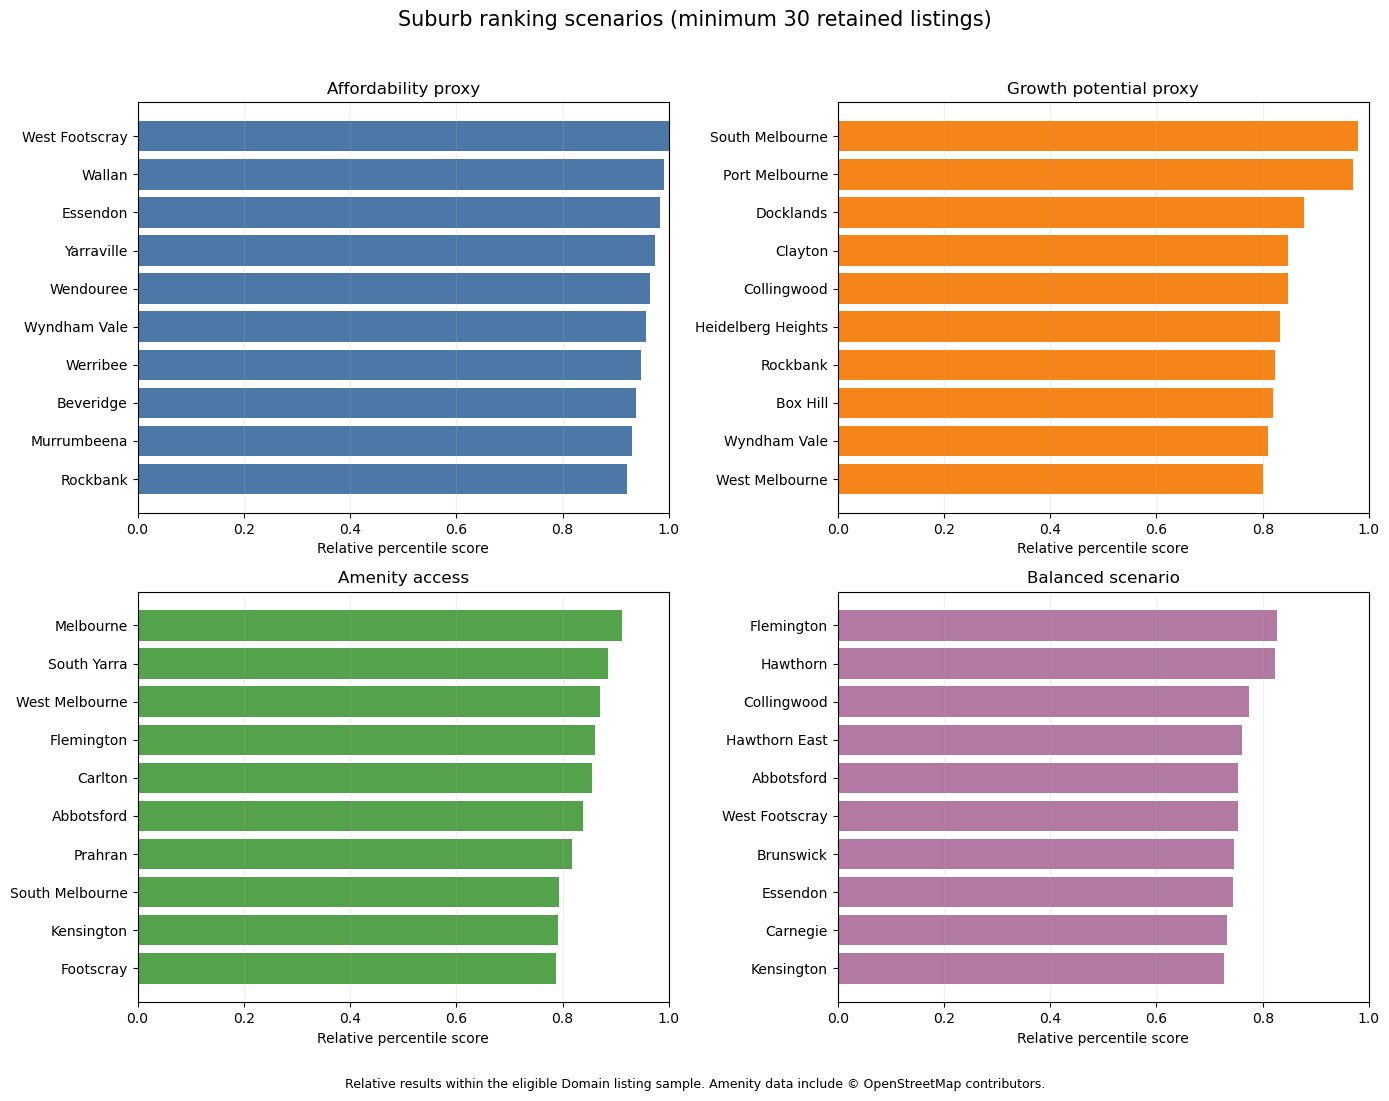

Wrote plots/05_suburb_ranking_top10.png


In [10]:
plot_specs = [
    ("affordability_score", "Affordability proxy", "#4C78A8"),
    ("growth_potential_score", "Growth potential proxy", "#F58518"),
    ("amenity_access_score", "Amenity access", "#54A24B"),
    ("balanced_score", "Balanced scenario", "#B279A2"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for ax, (score_column, title, colour) in zip(axes.flat, plot_specs):
    plot_data = ranked_suburbs.nlargest(TOP_N, score_column).sort_values(score_column)
    ax.barh(plot_data["suburb"].str.title(), plot_data[score_column], color=colour)
    ax.set_title(title)
    ax.set_xlabel("Relative percentile score")
    ax.set_xlim(0, 1)
    ax.grid(axis="x", alpha=0.2)

fig.suptitle(
    f"Suburb ranking scenarios (minimum {MIN_LISTINGS} retained listings)",
    fontsize=15,
    y=0.99,
)
fig.text(
    0.5,
    0.01,
    "Relative results within the eligible Domain listing sample. "
    "Amenity data include © OpenStreetMap contributors.",
    ha="center",
    fontsize=9,
)
plt.tight_layout(rect=[0, 0.035, 1, 0.97])

plot_path = PLOTS_DIR / "05_suburb_ranking_top10.png"
plt.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Wrote {plot_path.relative_to(PROJECT_ROOT)}")

## Interpretation and limitations

- Results describe advertised rents in a single Domain listing snapshot, not executed lease prices or the full rental stock.
- The whole-dwelling filter catches explicit text labels but may miss rooms whose listing text does not say room.
- Comparable rent controls for primary property type and bedroom count, but it is not a full hedonic adjustment. Predictions from the rental model can replace it once a validated per-listing prediction file is available.
- Median personal income is not household income. The affordability result must therefore be described as a proxy.
- A suburb can intersect several SA2s. Taking one value per contributing SA2 avoids listing-count weighting but is not a population- or area-weighted official correspondence.
- Amenity values describe the locations where listings occurred. OpenStreetMap park points use representative centres and can contain fragmented features.
- Growth potential combines a population forecast with historical income momentum. It is contextual evidence, not a forecast of rental-price growth.
- All scores are relative to suburbs meeting the selected listing threshold. Threshold and scenario sensitivity tables should accompany any published top-ten recommendation.